# 11 Decision Tree
### DECISION TREE
By **Mohan Sirumalla**
***


### Objective:
The objective of this assignment is to apply Decision Tree Classification to a given dataset, analyse
the performance of the model, and interpret the results.

### Task 1: Data Preparation

##### Import Library

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
# Define ANSI codes for clarity
BOLD = '\033[1m'
END = '\033[0m' # Resets the format


##### Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy)

##### Dataset is given in the excel format need to read excel

In [2]:
# Read all sheets into a dictionary of DataFrames
all_sheets = pd.read_excel('11_heart_disease.xlsx', sheet_name=None)
print(all_sheets.keys())

dict_keys(['Description', 'Heart_disease'])


In [3]:
df=all_sheets['Heart_disease']
df_org=df.copy() #Backup
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [4]:
# OR
# Read Data into seperate DataFrames
# Read a sheet named 'Description'
df_Description = pd.read_excel('11_heart_disease.xlsx', sheet_name='Description',header=None)

# # Read the second sheet (index 1)
df_Heart_disease = pd.read_excel('11_heart_disease.xlsx', sheet_name=1)

In [5]:
with pd.option_context('display.max_colwidth', None):
    print(df_Description[1])


0                                                                                                                                                                                                                                                                          Age in years
1                                                                                                                                                                                                                                                          Gender ; Male - 1, Female -0
2                                                                                                                                                                                                                                                                       Chest pain type
3                                                                                                                                                               

In [6]:
df_Heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [7]:
# df_Heart_disease not require so removeing from memory
import gc
if 'df_Heart_disease' in locals():
    del df_Heart_disease
    gc.collect() #Explicitly call gc.collect() after del to ensure the memory is released immediately.


### Task 2: Exploratory Data Analysis (EDA)

#### Perform exploratory data analysis to understand the structure of the dataset.

In [8]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [10]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')

##### Check Data Types: Ensure all columns are numeric.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [12]:
df.describe(include='all')

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
count,908.000000,908,908,908.000000,908.000000,908,908,908.000000,908,846.000000,908,908,908.000000
unique,NaN,2,4,NaN,NaN,2,3,NaN,4,NaN,3,3,NaN
top,NaN,Male,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,reversable defect,NaN
freq,NaN,718,495,NaN,NaN,723,542,NaN,516,NaN,453,372,NaN
mean,53.791850,NaN,NaN,133.430617,201.484581,NaN,NaN,135.957048,NaN,0.891253,NaN,NaN,1.008811
std,9.158031,NaN,NaN,20.401608,112.097949,NaN,NaN,26.804929,NaN,1.093875,NaN,NaN,1.144436
min,29.000000,NaN,NaN,0.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,NaN,0.000000
25%,47.750000,NaN,NaN,120.000000,176.750000,NaN,NaN,118.000000,NaN,0.000000,NaN,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,224.000000,NaN,NaN,138.000000,NaN,0.500000,NaN,NaN,1.000000
75%,60.000000,NaN,NaN,144.000000,270.000000,NaN,NaN,156.000000,NaN,1.500000,NaN,NaN,2.000000


#### Check for missing values, outliers, and inconsistencies in the data.

##### Check Duplicate Records

In [13]:
# Check Duplicate Records if any
if not df.duplicated().any():
    print("No Duplicates")
else:
    print("Duplicate records")

Duplicate records


In [14]:
# Select  numeric columns and non numeric columns
numeric_cols_df = df.select_dtypes(include='number')
print('Numberic',numeric_cols_df.columns)
non_numeric_cols_df = df.select_dtypes(exclude='number')
print('Non-Numberic',non_numeric_cols_df.columns)

Numberic Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num'], dtype='object')
Non-Numberic Index(['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object')


##### Check Null Values

In [15]:
#check for missing values, count them and print the sum for every column
print(df.loc[:, df.isnull().any()].isnull().sum())

oldpeak    62
dtype: int64


In [16]:
# Fill null values with mean or median based on outliers
# Calculate Q1, Q3, and IQR
column_name = 'oldpeak'
Q1 = df[column_name].quantile(0.25)
Q3 = df[column_name].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)]

# Print results
if not outliers.empty:
    print(f"Outliers exist in column '{column_name}':")
    #print(outliers)
else:
    print(f"No outliers detected in column '{column_name}' using the IQR method.")

Outliers exist in column 'oldpeak':


In [17]:
# outliers exist in oldpeak column so impute with Median
median_oldpeak = df[column_name].median() # Calculate the median of column 
#print(median_oldpeak)
df.fillna({median_oldpeak:median_oldpeak}, inplace=True) # Fill NaNs in 

##### Check Zero Value

In [18]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')

In [19]:
print(f"{BOLD}Zero Values Count{END}")

for col in numeric_cols_df:
    print(f"{col} :{numeric_cols_df[numeric_cols_df[col]==0].shape[0]} observations")


Zero Values Count
age :0 observations
trestbps :1 observations
chol :172 observations
thalch :0 observations
oldpeak :358 observations
num :399 observations


In [20]:
# trestbps :1 observations # invalid cannot be zero need to replace
# chol :172 observations # invalid cannot be zero need to replace
# oldpeak :358 observations # 0, representing no depression # 0 is valid
# num :399 observations 0=no heart disease  # 0 is valid

In [21]:
# repalce zero with null
df['trestbps'] = df['trestbps'].replace(0, np.nan)
df['chol'] = df['chol'].replace(0, np.nan)


In [22]:
missing_percentage = (df['trestbps'].isnull().sum() / len(df['trestbps'])) * 100
print(f"The Percentage of missing values in the 'trestbps' column is: {missing_percentage} %")

The Percentage of missing values in the 'trestbps' column is: 0.11013215859030838 %


In [23]:
median = df['trestbps'].median() # Calculate the median of column 
#print(median_oldpeak)
df.fillna({'trestbps':median}, inplace=True) # Fill NaNs in 

In [24]:
missing_percentage = (df['chol'].isnull().sum() / len(df['chol'])) * 100
print(f"The Percentage of missing values in the 'chol' column is: {missing_percentage} %")


The Percentage of missing values in the 'chol' column is: 18.94273127753304 %


In [25]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
# impute the missing values in the 'chol' column with the iterative imputer
# create object of the IterativeImputer
imputer= IterativeImputer(max_iter=10, random_state=42)

# fit and transform the entire DataFrame
df[['chol']] = imputer.fit_transform(df[['chol']])

# check and print the missing values in the 'trestbps' column with proper message
print(f"Now missing values in the 'chol' column is: {df['chol'].isnull().sum() / len(df['chol']) * 100} %")

Now missing values in the 'chol' column is: 0.0 %


In [26]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.573789,248.570652,135.957048,0.891253,1.008811
std,9.158031,19.914538,55.392897,26.804929,1.093875,1.144436
min,29.000000,80.000000,85.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,216.000000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,248.570652,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


#### Visualize the distribution of features, including histograms, box plots, and correlation matrices.

In [27]:
# Histograms :- to see if data is normally distributed or skewed

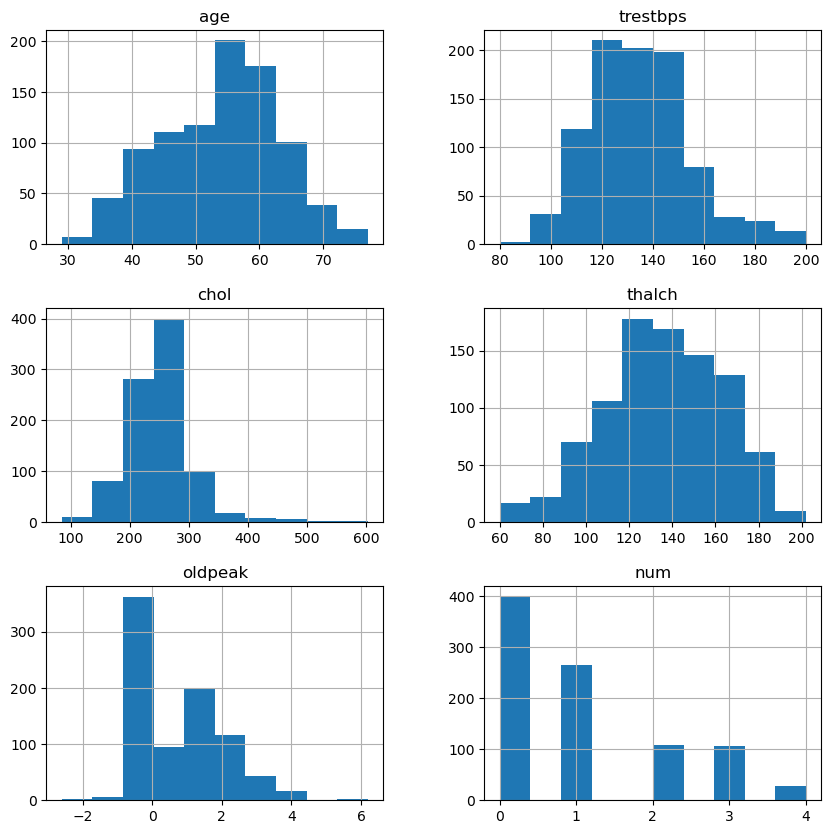

In [28]:
#histogram for each  feature
df.hist(bins=10,figsize=(10,10))
plt.show()

In [29]:
# Box Plot :- to analyse the distribution and see the outliers

In [30]:
numeric_cols_df.columns

Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num'], dtype='object')

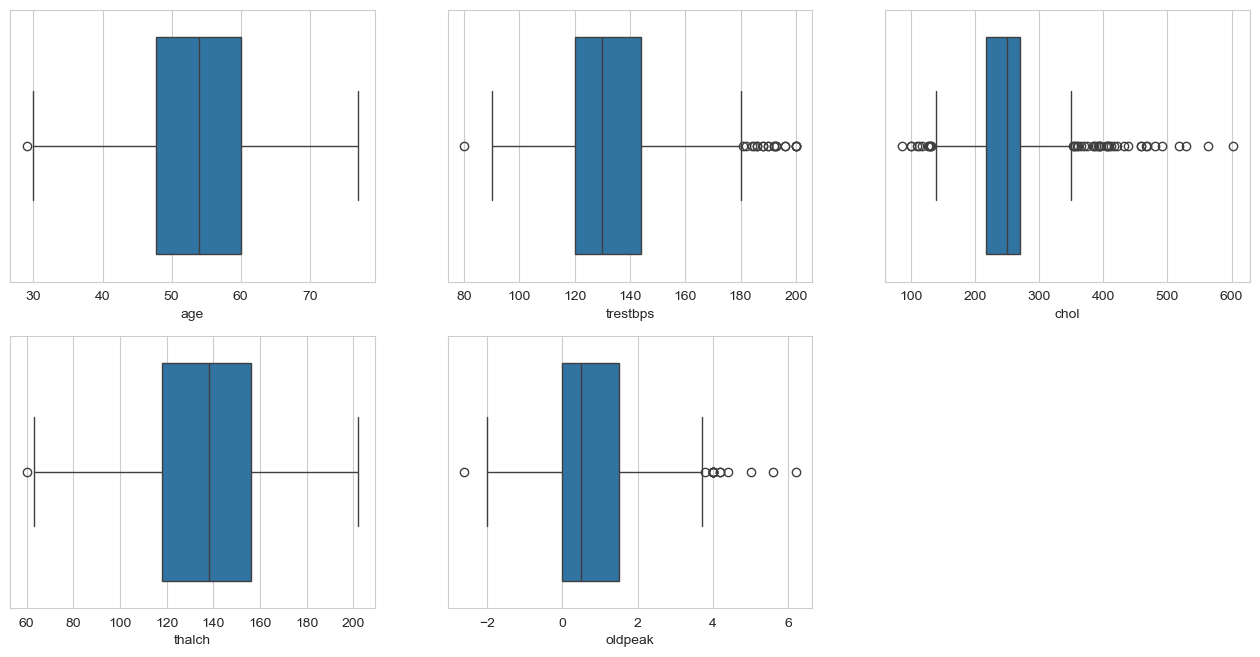

In [31]:
plt.figure(figsize=(16,12))
sns.set_style(style='whitegrid')
plt.subplot(3,3,1)
sns.boxplot(x='age',data=df)
plt.subplot(3,3,2)
sns.boxplot(x='trestbps',data=df)
plt.subplot(3,3,3)
sns.boxplot(x='chol',data=df)
plt.subplot(3,3,4)
sns.boxplot(x='thalch',data=df)
plt.subplot(3,3,5)
sns.boxplot(x='oldpeak',data=df)
plt.show()

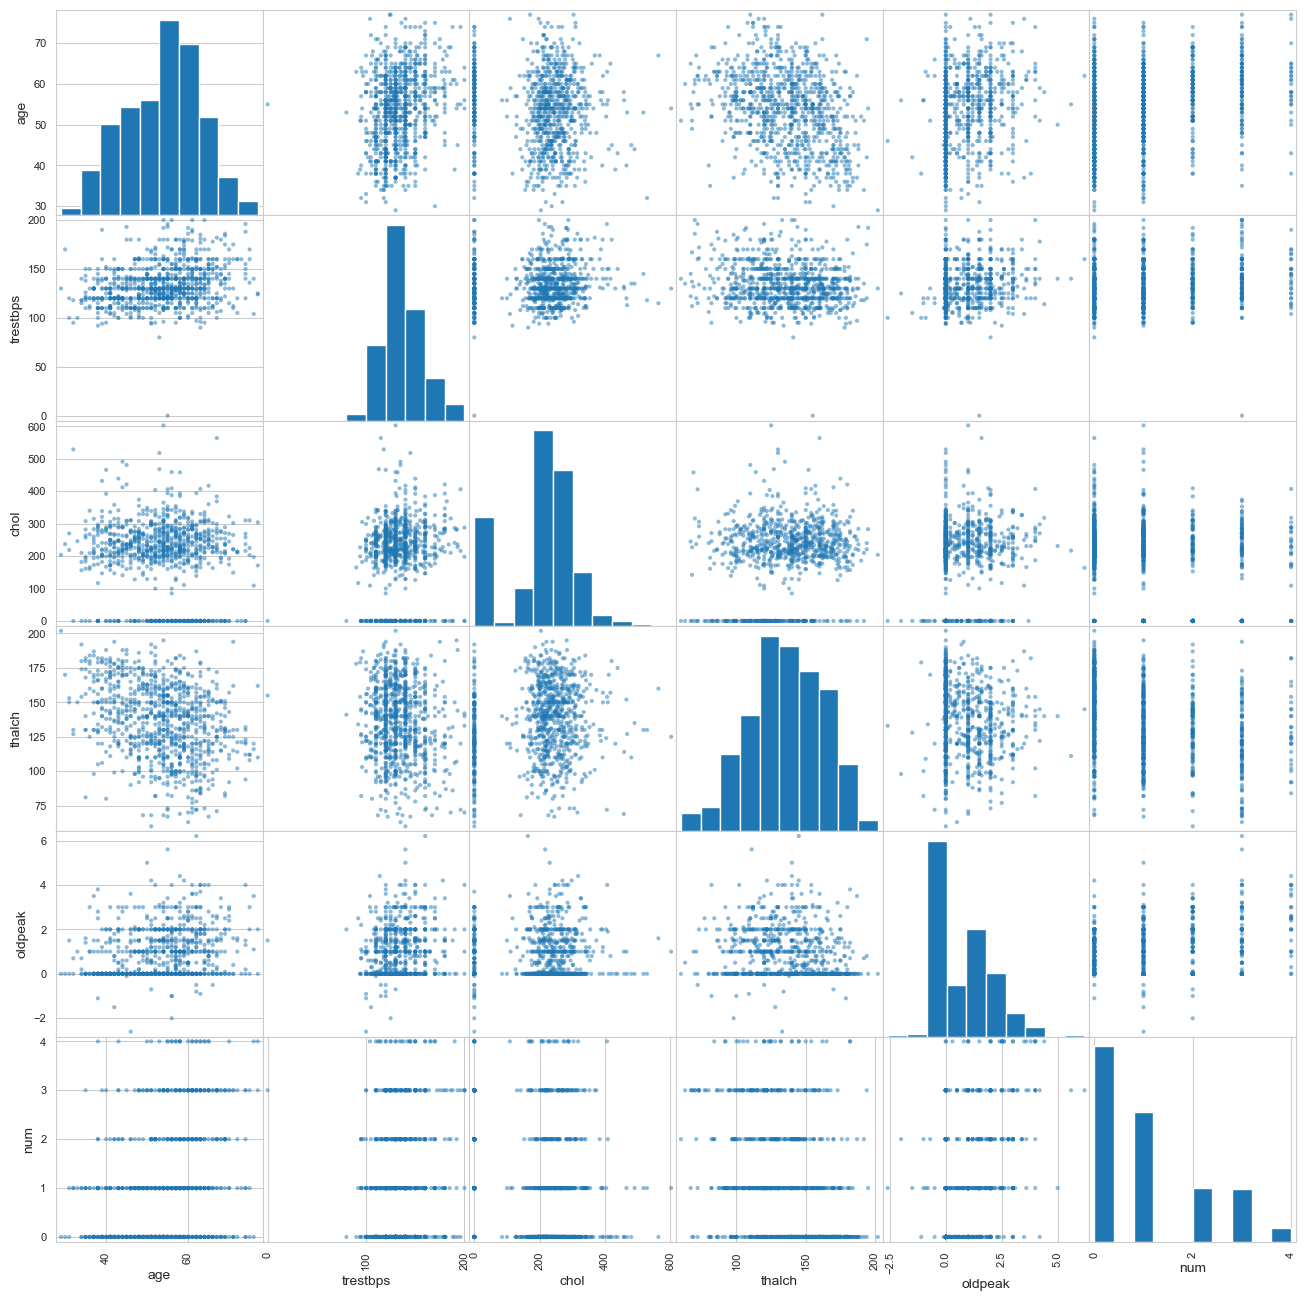

In [32]:
from pandas.plotting import scatter_matrix
scatter_matrix(numeric_cols_df,figsize=(16,16));

In [33]:
# Pair plot :- to create scatter plot between all the variables
numeric_cols_df.columns

Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num'], dtype='object')

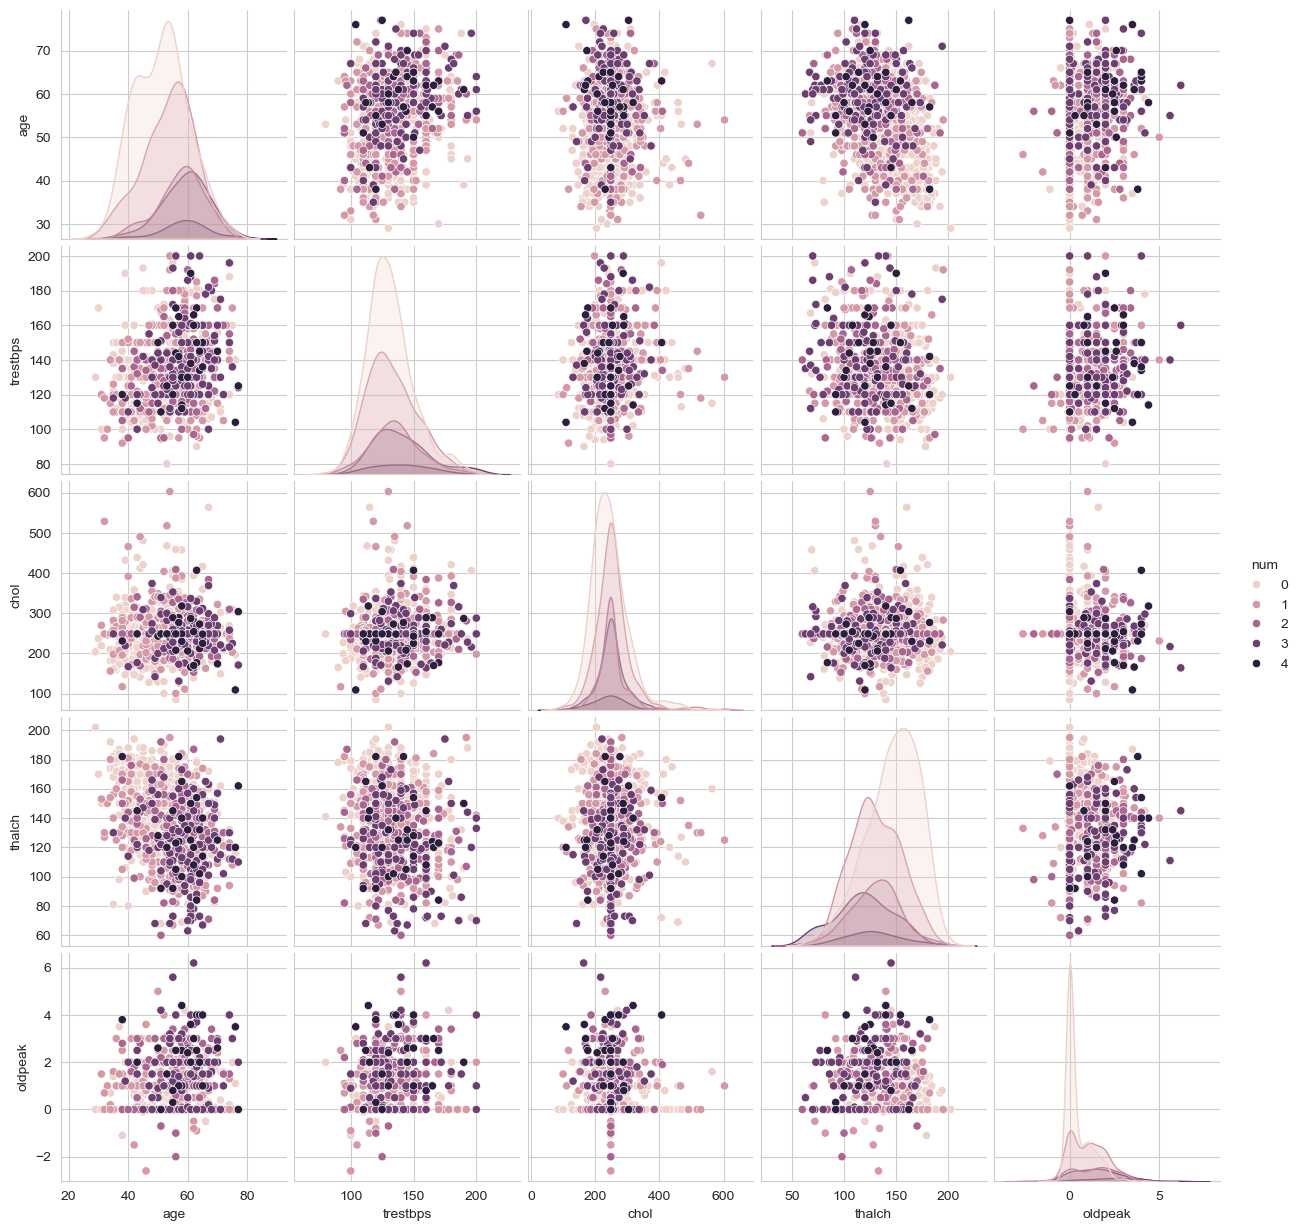

In [34]:
# Visualizing the relationships with a pairplot, colored by Outcome
sns.pairplot(df, hue='num', vars=['age', 'trestbps', 'chol', 'thalch', 'oldpeak'])
plt.show()

In [35]:
df.groupby('num').count() 

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal
num,,,,,,,,,,,,
0,399,399,399,399,399,399,399,399,399,378,399,399
1,265,265,265,265,265,265,265,265,265,250,265,265
2,109,109,109,109,109,109,109,109,109,101,109,109
3,107,107,107,107,107,107,107,107,107,91,107,107
4,28,28,28,28,28,28,28,28,28,26,28,28


<Axes: xlabel='num', ylabel='count'>

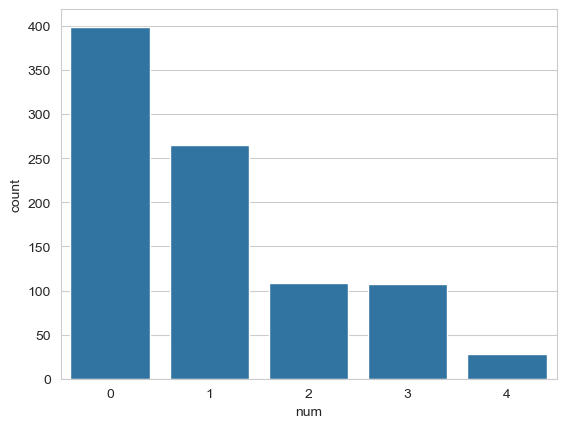

In [36]:
sns.countplot(x='num',data=df)

Mean: 53.791850220264315
Median: 54.0
Mode: 54


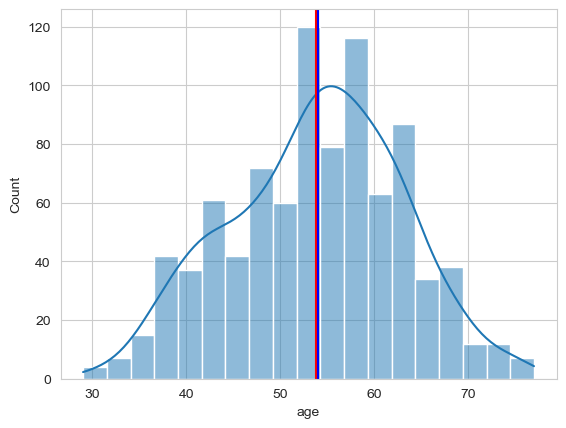

In [37]:
sns.histplot(df['age'], kde=True)
plt.axvline(df['age'].mean(), color='red')
plt.axvline(df['age'].median(), color='green')
#  Since mode returns a Series, [0] is used to get the first mode (assuming there is only one mode).
plt.axvline(df['age'].mode()[0], color='blue')

# print the value of mean, median and mode of age column
print('Mean:', df['age'].mean())
print('Median:', df['age'].median())
print('Mode:', df['age'].mode()[0])

<Axes: xlabel='cp', ylabel='count'>

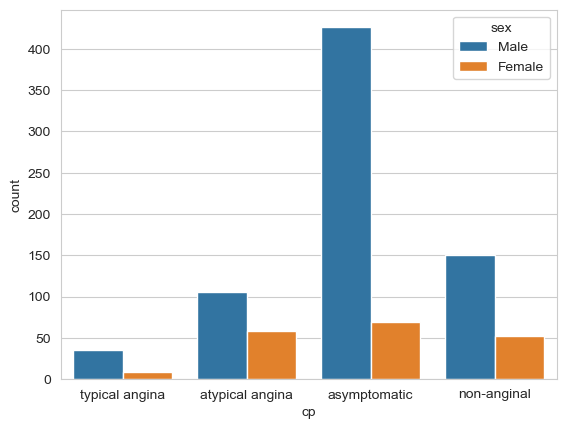

In [38]:
# Count plot with the help of "seaborn"
sns.countplot(df, x="cp", hue="sex")

#### Investigate feature correlations to discern relationships within the data.

In [39]:
# Feature Selection

<Axes: >

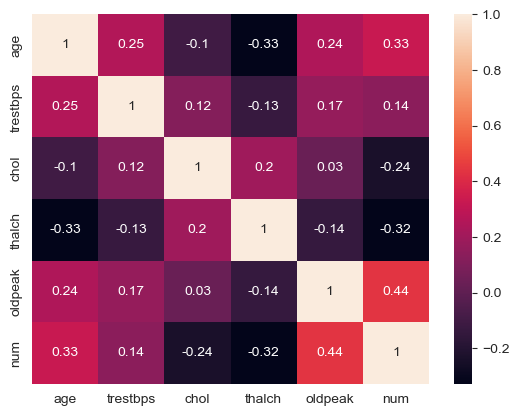

In [40]:
corrmat=numeric_cols_df.corr()
sns.heatmap(corrmat, annot=True)

### Task 3: Feature Engineering:

In [41]:
for col in non_numeric_cols_df.columns:
    print(col,df[col].unique())

sex ['Male' 'Female']
cp ['typical angina' 'atypical angina' 'asymptomatic' 'non-anginal']
fbs [ True False]
restecg ['lv hypertrophy' 'normal' 'st-t abnormality']
exang [False True 'FALSE' 'TURE']
slope ['downsloping' 'flat' 'upsloping']
thal ['fixed defect' 'normal' 'reversable defect']


In [42]:
# exang having mix values
mapping_dict = {
    'True': True,
    'False': False,
    'TRUE': True,
    'FALSE': False,
    'TURE': True,  # Fix the typo
    True: True,    # Map existing boolean True to True
    False: False,  # Map existing boolean False to False
}

# Apply the mapping to the column
df['exang'] = df['exang'].map(mapping_dict)

In [43]:
for col in non_numeric_cols_df.columns:
    print(col,df[col].unique())

sex ['Male' 'Female']
cp ['typical angina' 'atypical angina' 'asymptomatic' 'non-anginal']
fbs [ True False]
restecg ['lv hypertrophy' 'normal' 'st-t abnormality']
exang [False  True]
slope ['downsloping' 'flat' 'upsloping']
thal ['fixed defect' 'normal' 'reversable defect']


#### 1. scaling numerical features

In [44]:
numeric_cols_df.columns

Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num'], dtype='object')

In [45]:
from sklearn.preprocessing import StandardScaler
numerical_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

# 1. Instantiate the StandardScaler
scaler = StandardScaler()

# 2. Fit and transform the selected columns
# The output of fit_transform() is a NumPy array
scaled_data = scaler.fit_transform(df[numerical_cols])

# 3. Assign the scaled data back to the DataFrame
# The columns and index must be aligned
df[numerical_cols] = scaled_data

#### 2. ncoding categorical variables

In [46]:
non_numeric_cols_df.columns

Index(['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object')

In [47]:
for col in non_numeric_cols_df.columns:
    print(df[col].unique())

['Male' 'Female']
['typical angina' 'atypical angina' 'asymptomatic' 'non-anginal']
[ True False]
['lv hypertrophy' 'normal' 'st-t abnormality']
[False  True]
['downsloping' 'flat' 'upsloping']
['fixed defect' 'normal' 'reversable defect']


**Here is the likely order for each feature:**
  *  ['Male' 'Female']\
        Order: Male, Female (often encoded as 1 and 0 respectively).
  *  ['typical angina' 'atypical angina' 'asymptomatic' 'non-anginal']\
        Order (cp - Chest Pain Type): This often follows 1: typical, 2: atypical, 3: non-anginal, 4: asymptomatic.
  *  [ True False]\
        Order (fbs - Fasting Blood Sugar > 120 mg/dl): True (1), False (0).
  *  ['lv hypertrophy' 'normal' 'st-t abnormality']\
        Order (restecg - Resting Electrocardiographic Results): Usually 0: Normal, 1: ST-T abnormality, 2: LV hypertrophy.
  *  [False True 'FALSE' 'TURE']\
        Order (exang - Exercise Induced Angina): Refers to boolean (False=0, True=1). Note: 'TURE' is likely a typo for 'TRUE' in the source.
  * ['downsloping' 'flat' 'upsloping']\
        Order (slope - Slope of the peak exercise ST segment): Commonly 0: upsloping, 1: flat, 2: downsloping.
  * ['fixed defect' 'normal' 'reversable defect']\
        Order (thal - Thalassemia): Usually 1: normal, 2: fixed defect, 3: reversible defect.

In [48]:
 non_numeric_cols_df.columns

Index(['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object')

In [49]:
df_org = df.copy()

In [50]:
df_encoded = df_org.copy()

In [51]:
## Ordinal Data Label Encoding

In [52]:
from sklearn.preprocessing import OrdinalEncoder

# Define custom orderings
sex_order = ['Male', 'Female']# only 2 category assumed to be ordinal
cp_order = ['typical angina', 'atypical angina' , 'non-anginal','asymptomatic']
fbs_order = [ False,True]
restecg_order = ['normal','st-t abnormality','lv hypertrophy']
exang_order = [ False,True]
slope_order = ['upsloping','flat','downsloping' ]
thal_order = ['normal','fixed defect' , 'reversable defect']


# Instantiate encoder with specified categories
encoder = OrdinalEncoder(categories=[sex_order, cp_order,fbs_order,restecg_order,exang_order,slope_order,thal_order])
cols_to_encode = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

encoded_data = encoder.fit_transform(df_encoded[cols_to_encode])

df_encoded[cols_to_encode] = encoded_data
print("\nDataFrame with encoded values:")
#print(df_encoded)

# 6. Display the assigned mapping for each column using the categories_ attribute
print("\nAssigned values (mapping):")
for i, col in enumerate(cols_to_encode):
    mapping = dict(zip(encoder.categories_[i], range(len(encoder.categories_[i]))))
    print(f"- '{col}' column mapping: {mapping}")
df_encoded['sex']
df[['sex']]=df_encoded[['sex']]
df[['cp']]=df_encoded[['cp']]
df[['fbs']]=df_encoded[['fbs']]
df[['restecg']]=df_encoded[['restecg']]
df[['exang']]=df_encoded[['exang']]
df[['slope']]=df_encoded[['slope']]
df[['thal']]=df_encoded[['thal']]
df
# Transform data
#df[cols_to_encode] = encoder.fit_transform(df[cols_to_encode])
#df[['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']] = encoder.fit_transform(df[['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']])
#print(df)

#df.head()



DataFrame with encoded values:

Assigned values (mapping):
- 'sex' column mapping: {'Male': 0, 'Female': 1}
- 'cp' column mapping: {'typical angina': 0, 'atypical angina': 1, 'non-anginal': 2, 'asymptomatic': 3}
- 'fbs' column mapping: {np.False_: 0, np.True_: 1}
- 'restecg' column mapping: {'normal': 0, 'st-t abnormality': 1, 'lv hypertrophy': 2}
- 'exang' column mapping: {np.False_: 0, np.True_: 1}
- 'slope' column mapping: {'upsloping': 0, 'flat': 1, 'downsloping': 2}
- 'thal' column mapping: {'normal': 0, 'fixed defect': 1, 'reversable defect': 2}


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,1.006027,0.0,0.0,0.574079,-0.281250,1.0,2.0,0.524183,0.0,1.288612,2.0,1.0,0
1,-1.397560,0.0,1.0,0.071656,-0.823134,0.0,0.0,-0.147705,0.0,-0.815249,1.0,1.0,0
2,0.350503,0.0,3.0,0.322867,-1.021825,0.0,0.0,0.449529,0.0,-0.449360,1.0,1.0,0
3,-0.195767,0.0,0.0,-0.782462,-1.130202,0.0,2.0,2.017268,0.0,-0.815249,1.0,1.0,0
4,0.350503,0.0,3.0,-1.184400,-0.859259,0.0,0.0,-0.371668,1.0,0.556834,1.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,-0.086513,0.0,3.0,-0.430766,0.000000,0.0,0.0,-0.595631,0.0,0.556834,0.0,0.0,4
904,0.896773,0.0,3.0,1.629166,-1.419206,0.0,1.0,-0.595631,1.0,1.928917,1.0,2.0,4
905,0.241249,0.0,2.0,1.830135,0.000000,0.0,2.0,-0.483649,1.0,1.471556,2.0,2.0,4
906,0.241249,0.0,2.0,0.523836,-0.732820,1.0,1.0,-1.155538,1.0,NaN,2.0,2.0,4


### Task 4: Decision Tree Classification:

#### Split the dataset into training and testing sets (e.g., using an 80-20 split)

In [53]:
#Split the Data Frame into X and y Features and Target

In [54]:
# data partition
df_new = df.copy()
target_name='num'
y= df_new[target_name]#given predictions - training data 
X=df_new.drop(target_name,axis=1)#dropping the Drug Response column and keeping 

In [55]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal
0,1.006027,0.0,0.0,0.574079,-0.281250,1.0,2.0,0.524183,0.0,1.288612,2.0,1.0
1,-1.397560,0.0,1.0,0.071656,-0.823134,0.0,0.0,-0.147705,0.0,-0.815249,1.0,1.0
2,0.350503,0.0,3.0,0.322867,-1.021825,0.0,0.0,0.449529,0.0,-0.449360,1.0,1.0
3,-0.195767,0.0,0.0,-0.782462,-1.130202,0.0,2.0,2.017268,0.0,-0.815249,1.0,1.0
4,0.350503,0.0,3.0,-1.184400,-0.859259,0.0,0.0,-0.371668,1.0,0.556834,1.0,1.0


In [56]:
y.head() #contains dependent feature

0    0
1    0
2    0
3    0
4    0
Name: num, dtype: int64

In [57]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=42)#splitting data in 80% train, 20%test

In [58]:
print('Total',len(df))
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

Total 908
(726, 12) (726,)
(182, 12) (182,)


#### Implement a Decision Tree Classification model 

In [59]:
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(726, 12) (726,)
(182, 12) (182,)


In [60]:
from sklearn.tree import DecisionTreeClassifier
# Create Decision Tree classifier object
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3) # Criterion can be 'gini' or 'entropy'
#clf = DecisionTreeClassifier(criterion='gini') # Criterion can be 'gini' or 'entropy'


In [61]:
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

In [62]:
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)


In [63]:
print(y_pred_train)
print(y_pred_test)

[0 0 0 0 0 3 1 0 1 0 0 1 1 0 0 0 0 1 0 0 1 1 0 1 1 0 1 0 1 1 0 0 1 1 0 0 0
 0 1 1 1 0 0 1 0 0 1 0 1 0 0 0 0 3 0 3 3 0 1 1 1 1 0 0 3 0 0 0 0 1 0 0 0 0
 1 1 1 0 0 0 0 1 0 0 1 0 1 1 0 1 1 3 0 0 3 0 0 1 0 0 3 0 1 0 0 1 0 0 0 0 0
 0 0 3 0 0 1 0 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 3 1 1 0 0 0
 3 0 3 1 3 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1 3 1 1 0 0 0
 1 0 0 0 0 0 0 0 0 0 1 0 0 1 3 0 1 1 0 1 1 0 0 0 0 3 1 1 0 1 0 0 1 0 1 0 1
 0 0 0 0 0 1 1 0 1 0 3 1 1 0 0 0 1 0 0 1 0 0 0 0 0 3 1 3 1 0 0 1 0 1 0 0 1
 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 3 0 0 0 3 0 0 1 0 0 0 3 0 1 1 1 0 0 3
 0 0 0 0 0 0 0 0 0 3 0 1 0 1 0 0 0 1 0 1 0 0 0 0 0 3 1 0 0 3 1 0 3 0 3 0 1
 1 0 0 0 1 0 3 1 0 3 0 1 0 1 0 0 3 0 3 0 3 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0
 1 0 1 0 0 0 1 1 0 0 3 1 0 0 0 0 0 0 1 0 0 0 1 0 1 0 1 0 0 1 0 1 0 0 0 1 1
 1 3 0 0 0 3 0 0 3 0 1 3 0 0 0 0 0 0 0 0 0 0 1 1 3 0 1 3 1 3 1 0 1 0 0 0 0
 0 0 0 1 0 3 3 0 0 0 1 0 3 0 1 0 1 0 0 1 3 0 0 0 0 0 0 3 0 1 3 0 1 0 0 1 0
 0 0 0 0 0 3 0 0 1 3 1 0 

In [64]:
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test, target_names=['no heart disease','Stage 1','Stage 2','Stage 3','Stage 4'],zero_division=0))


Accuracy: 0.5824175824175825

Classification Report:
                   precision    recall  f1-score   support

no heart disease       0.68      0.91      0.78        89
         Stage 1       0.47      0.48      0.47        48
         Stage 2       0.00      0.00      0.00        22
         Stage 3       0.14      0.12      0.13        17
         Stage 4       0.00      0.00      0.00         6

        accuracy                           0.58       182
       macro avg       0.26      0.30      0.28       182
    weighted avg       0.47      0.58      0.52       182



In [65]:
# ROC-AUC SCORE

In [66]:
from sklearn.metrics import roc_auc_score

y_pred_proba = clf.predict_proba(X_test)

roc_auc_ovr_macro = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
roc_auc_ovr_weighted = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')

print(f"Macro-averaged One-vs-Rest ROC AUC score: {roc_auc_ovr_macro:.4f}")
print(f"Weighted-averaged One-vs-Rest ROC AUC score: {roc_auc_ovr_weighted:.4f}")


Macro-averaged One-vs-Rest ROC AUC score: 0.7402
Weighted-averaged One-vs-Rest ROC AUC score: 0.7866


### Task 5: Hyperparameter Tuning

#### 1. Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.

In [67]:
from sklearn.model_selection import train_test_split, GridSearchCV
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

# 3. Perform Grid Search (5-fold cross-validation)
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# 4. Results
print(f"Best Params: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")
print(f"Test Accuracy: {grid_search.score(X_test, y_test):.4f}")

Best Params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Best CV Score: 0.5372
Test Accuracy: 0.5879


### Task 6:Model Evaluation and Analysis

#### 1. Analyse the performance of the Decision Tree model using the evaluation metrics obtained

In [68]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
accuracy = accuracy_score(y_test, y_pred_test)
print(f"Accuracy: {accuracy}\n") #

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:")
print(conf_matrix)

print("-" * 50)

# Classification Report (Precision, Recall, F1-Score, Support for each class)
class_report = classification_report(y_test, y_pred_test,zero_division=0)
print("Classification Report:")
print(class_report) #

Accuracy: 0.5824175824175825

Confusion Matrix:
[[81  7  0  1  0]
 [21 23  0  4  0]
 [ 8  8  0  6  0]
 [ 6  9  0  2  0]
 [ 3  2  0  1  0]]
--------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.91      0.78        89
           1       0.47      0.48      0.47        48
           2       0.00      0.00      0.00        22
           3       0.14      0.12      0.13        17
           4       0.00      0.00      0.00         6

    accuracy                           0.58       182
   macro avg       0.26      0.30      0.28       182
weighted avg       0.47      0.58      0.52       182



#### 2 Visualize the decision tree structure to understand the rules learned by the model and identify important features

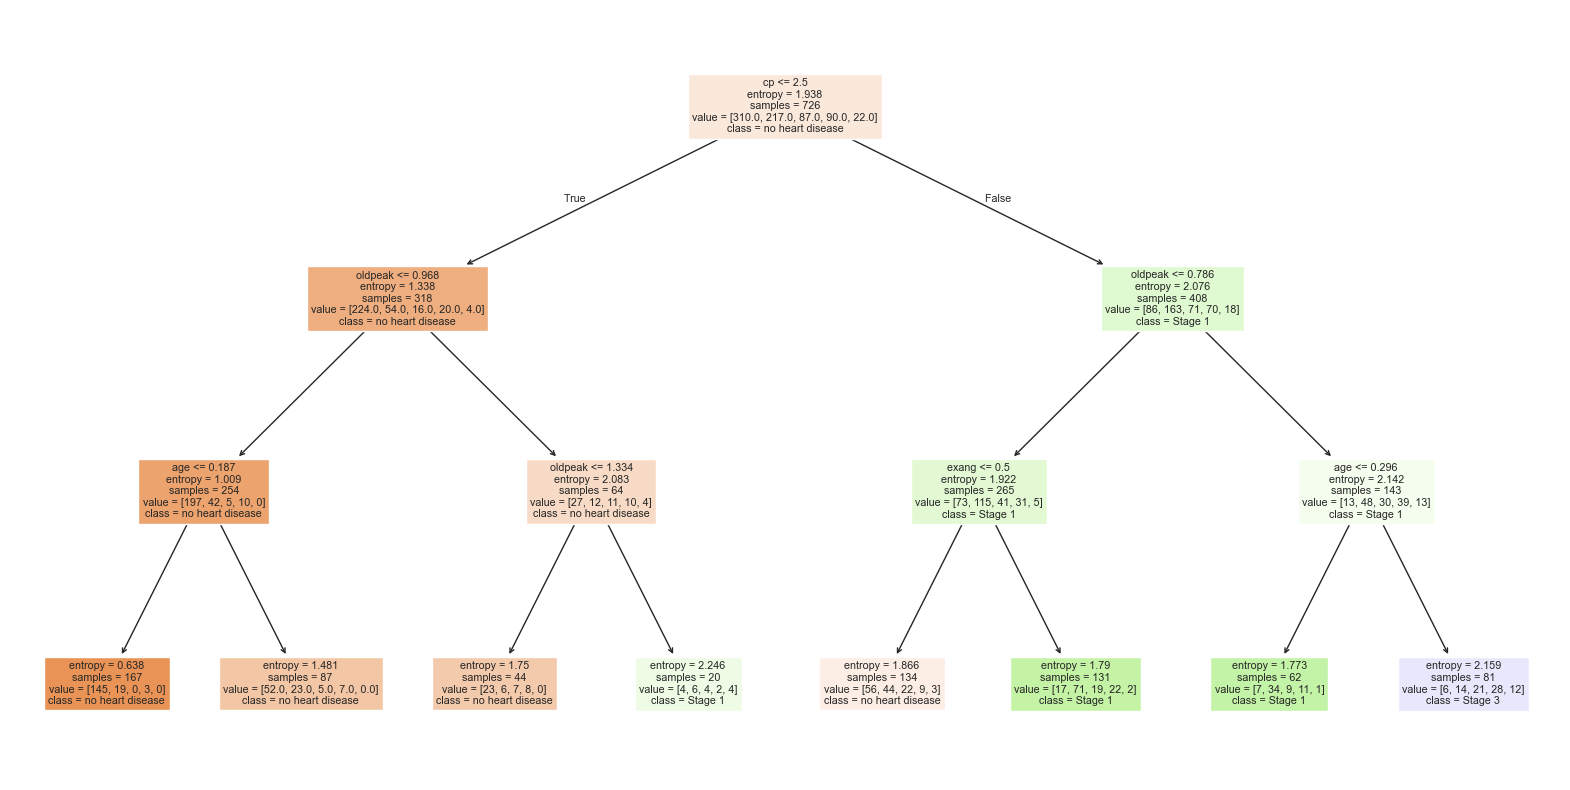

In [69]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(
    clf,  # Get the first fitted estimator from cross-validation
    filled=True,
    feature_names=X.columns,
    class_names=['no heart disease','Stage 1','Stage 2','Stage 3','Stage 4'],
)
plt.show()

### Interview Questions:

#### 1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance

**Key Decision Tree Hyperparameters and Their Effects:**
  * **max_depth (Maximum Depth):** Limits how deep the tree can grow. A higher value allows the model to capture more complex patterns but increases overfitting risk.
  * **min_samples_split (Minimum Samples to Split):** The minimum number of samples required to split an internal node. Increasing this value prevents the tree from creating nodes that are too specific, reducing overfitting.
  * **min_samples_leaf (Minimum Samples per Leaf):** Ensures each leaf node has a minimum number of samples. Higher values make the model more generalized, reducing overfitting by preventing the model from learning from noise or anomalous, tiny observations.
  * **max_features (Maximum Features):** The number of features to consider when looking for the best split. Limiting this reduces model variance (overfitting) and makes the model faster, as it doesn't evaluate all features every time.
  * **criterion (Split Quality):** The function to measure the quality of a split, such as 'gini' for Gini impurity or 'entropy' for information gain. The choice affects how the tree chooses splits.
  * **min_impurity_decrease (Minimum Impurity Decrease):** A node is split only if the split induces a decrease of the impurity greater than or equal to this value. This acts as a threshold for pruning, where a higher value forces a simpler model.
  * **max_leaf_nodes (Maximum Leaf Nodes):** Restricts the total number of leaf nodes, growing the tree in a best-first fashion until this limit is reached, which helps in controlling model size.
    

#### 2. What is the difference between the Label encoding and One-hot encoding

|Aspect|One Hot Encoding|Label Encoding|
|----|---|---|
|Nature of Data|	Best for nominal data (no order)	|Best for ordinal data (has a natural order)|
|Number of Features Created	|Creates multiple binary features per category	|Creates a single integer-valued feature|
|Model Interpretation	|Easy to interpret, each column corresponds to a category	|Harder to interpret, categories are replaced by integers|
|Impact on Machine Learning	|Suitable for algorithms that don't assume ordinality	|Suitable for tree-based models that handle ordinal data|
|Dimensionality|	Increases dimensionality, leading to sparse data	|Does not increase dimensionality, more compact|
|Handling Unseen Categories	|Can raise errors unless handled explicitly	|Can assign arbitrary integers to unseen categories|
|Memory and Computational Efficiency	|Less memory efficient, increases computation	|More memory efficient and computationally cheaper|